In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
from typing import Optional

from IPython.display import Image
from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from utilsforecast.losses import rmse, mae

In [3]:
google = (
    pd.read_csv("gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "GOOG_Close")
        & (x["ds"].dt.year == 2015)
    ]
    .reset_index()
)

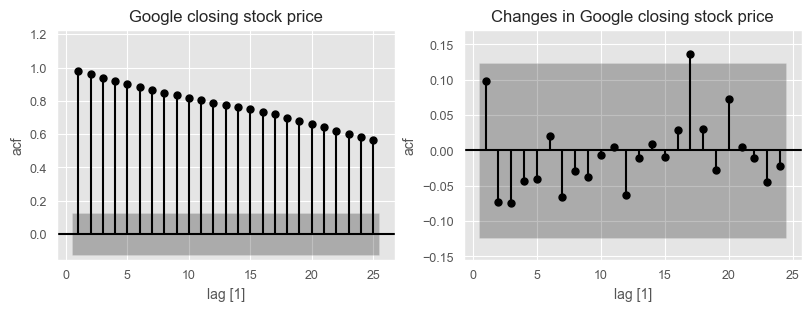

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_acf(
    google["y"], ax=axes[0], zero=False,
    title="Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
plot_acf(
    google["y"].diff().iloc[1:], ax=axes[1], zero=False,
    title="Changes in Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
for ax in axes:
    ax.set(xlabel="lag [1]", ylabel="acf")
plt.show()

In [5]:
ljung_box = acorr_ljungbox(google["y"].diff()[1:], lags=[10])
ljung_box

,lb_stat,lb_pvalue
10,7.914,0.637


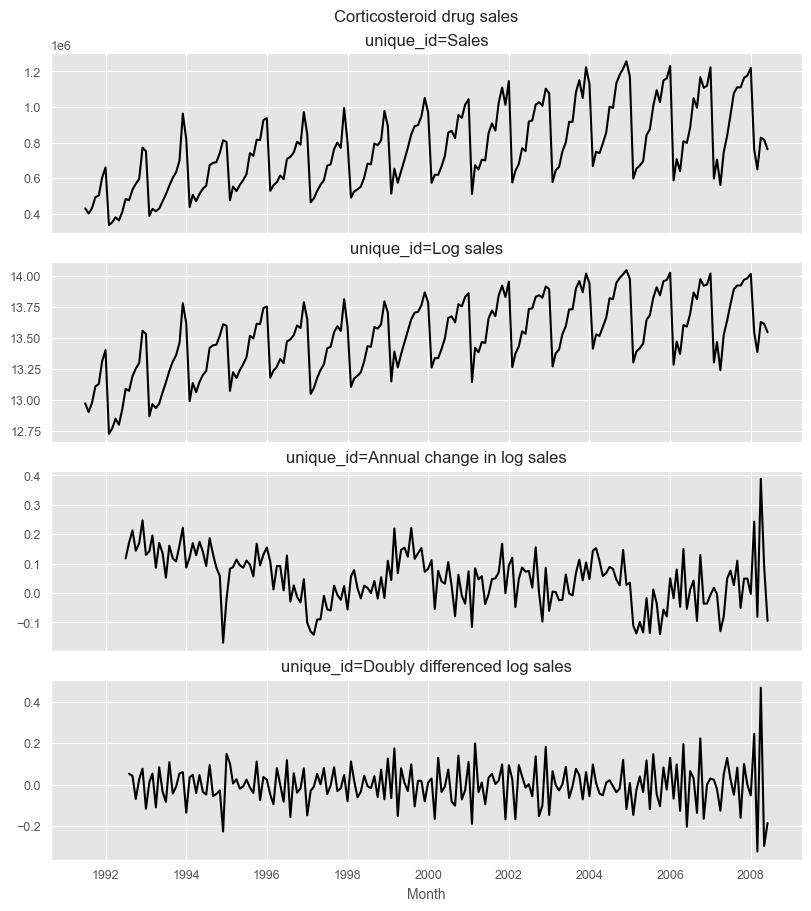

In [6]:
order = {
    "sales": 0, "log_sales": 1,
    "diff_log_sales": 2, "ddiff_log_sales": 3}
renames = {
    "sales": "Sales", "log_sales": "Log sales",
    "diff_log_sales": "Annual change in log sales",
    "ddiff_log_sales": "Doubly differenced log sales",
}
pbs = (
    pd.read_csv("PBS_unparsed.csv", parse_dates=["Month"])
    .rename(columns={"Month": "ds"})
    .loc[lambda x: x["ATC2"] == "H02"]
    .groupby("ds")["Cost"].sum()
    .rename("sales").reset_index()
    .assign(
        log_sales=lambda x: np.log(x["sales"]),
        diff_log_sales=lambda x: x["log_sales"].diff(12),
        ddiff_log_sales=lambda x: x["diff_log_sales"].diff(),
    )
    # Rearrange into long form
    .melt(id_vars=["ds"], var_name="unique_id", value_name="y")
    .assign(order=lambda x: x["unique_id"].map(order))
    .sort_values(["order", "ds"])
    .assign(unique_id=lambda x: x["unique_id"].map(renames))
)

fig, axes = plt.subplots(4, figsize=(8, 9), sharex=True)
plot_series_utils(pbs, ax=axes)
for ax in axes:
    ax.set(ylabel="")
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
ax.set(xlabel="Month")
fig.legends = []
fig.suptitle("Corticosteroid drug sales", x=0.525)
fig

In [7]:
kpss_stat, kpss_pvalue, *_ = kpss(google["y"], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat: 3.561
kpss_pvalue: 0.01


C:\Users\HP\AppData\Local\Temp\ipykernel_23992\1367699554.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(google["y"], nlags = 5)


In [8]:
kpss_stat, kpss_pvalue, *_ = kpss(google["y"].diff()[1:], nlags=5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat: 0.099
kpss_pvalue: 0.10


C:\Users\HP\AppData\Local\Temp\ipykernel_23992\3486560393.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(google["y"].diff()[1:], nlags=5)


In [9]:
ndiffs(google["y"].to_numpy())

1

In [11]:
aus_total_retail = (
    pd.read_csv("aus_retail.csv", parse_dates=["Month"])
    .groupby("Month", as_index=False)
    ["Turnover"].sum()
    .assign(**{"log(Turnover)": lambda x: np.log(x["Turnover"])})
)

In [12]:
# Test for seasonal differencing
nsdiffs(aus_total_retail["log(Turnover)"].values, period=12)

1

In [13]:
# Apply seasonal difference before testing for first differencing
ndiffs(aus_total_retail["log(Turnover)"].diff(12)[1:].values)

1